In [291]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity

In [292]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [328]:
class network_wake(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.linear_sleep = nn.Linear(hidden_sleep_size*num_layers_sleep, len(tokens))
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, hw=None, hs=None):        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)
        
        # if hs != None:
        #     sleep_out = self.linear_sleep(hs.view(-1))
        #     out = out + sleep_out

        return out, hw

In [329]:
class network_sleep(nn.Module):
    def __init__(self, input_size, hidden_sleep_size, num_layers=1):
        super(network_sleep, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_sleep_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, len(tokens))

    def forward(self, x, hs=None):
        if hs == None:
            out, hs = self.rnn(x)
        else:
            out, hs = self.rnn(x, hs)

        out = self.sleep_fc(out)
        
        return out, hs

In [330]:
class compressor(nn.Module):
    def __init__(self, input_size, hidden_compressor_size, num_layers=1):
        super(compressor, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_compressor_size, num_layers, nonlinearity='relu', batch_first=True)
        self.compressor_fc = nn.Linear(hidden_compressor_size, 2)

    def forward(self, x, hc=None):
        if hc == None:
            out, hc = self.rnn(x)
        else:
            out, hc = self.rnn(x, hc)

        out = self.compressor_fc(out)
        
        return out, hc

In [331]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [332]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [333]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [343]:
### initial training ###
total_samples = 40000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_compressor_size = 5
hidden_sleep_size = 500
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members)
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 1.8754, accuracy: 0.2230
Iter : 2001, loss: 2.3636, accuracy: 0.3440
Iter : 3001, loss: 1.6099, accuracy: 0.4030
Iter : 4001, loss: 2.4342, accuracy: 0.5400
Iter : 5001, loss: 2.4086, accuracy: 0.6240
Iter : 6001, loss: 2.0895, accuracy: 0.6970
Iter : 7001, loss: 0.8599, accuracy: 0.7100
Iter : 8001, loss: 1.7527, accuracy: 0.7480
Iter : 9001, loss: 0.8988, accuracy: 0.7440
Iter : 10001, loss: 1.7436, accuracy: 0.7350
Iter : 11001, loss: 0.8245, accuracy: 0.7460
Iter : 12001, loss: 1.9938, accuracy: 0.7380
Iter : 13001, loss: 2.5825, accuracy: 0.7530
Iter : 14001, loss: 1.7430, accuracy: 0.7330
Iter : 15001, loss: 0.9870, accuracy: 0.7650
Iter : 16001, loss: 1.7222, accuracy: 0.7410
Iter : 17001, loss: 2.2631, accuracy: 0.7480
Iter : 18001, loss: 1.7229, accuracy: 0.7500
Iter : 19001, loss: 1.7958, accuracy: 0.7470
Iter : 20001, loss: 2.0401, accuracy: 0.7450
Iter : 21001, loss: 1.8998, accuracy: 0.7510
Iter : 22001, loss: 1.2977, accuracy: 0.7520
Iter : 23001, loss:

In [344]:
compressor_sample = 10000

data_compressor = get_sequence(compressor_sample, n_community, n_members)
data_set_compressor = Dataset_converter(data_compressor, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# community = ''

with torch.no_grad():
    for X, _ in compressor_loader:
        if ii==0:
            id, hw = network1(X)
            id_current = hw
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = network1(X, hw=hw)
            id_current = hw
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [345]:
dis_array = np.array(dis)
threshold = np.quantile(dis_array, .6)

mask = ((dis_array>threshold)*1)

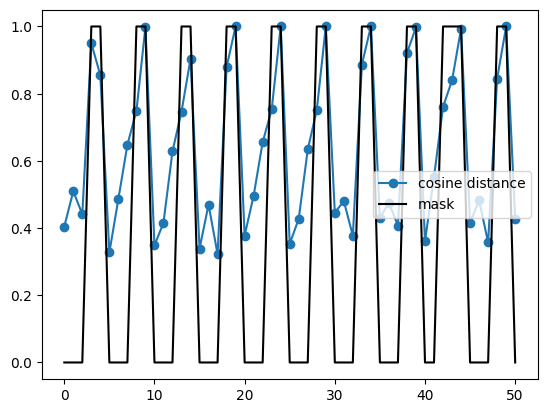

In [346]:
span = 51
plt.plot(dis[1:span+1], '-o', label='cosine distance')
plt.plot(mask[1:span+1], c='k', label = 'mask')
plt.legend()

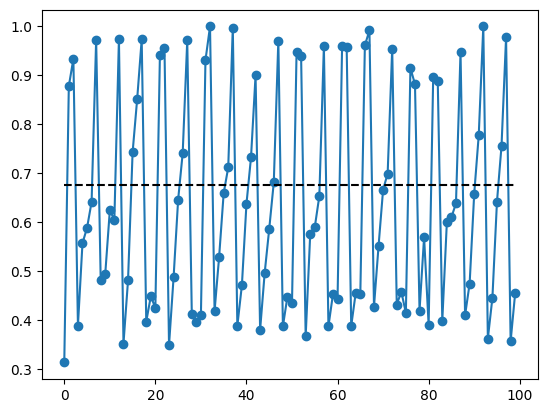

In [347]:
span = 100
plt.plot(dis[-span:], '-o')
plt.plot(np.arange(span), [threshold]*span, '--', c='k')

In [348]:
mask[-100:]

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0])

In [349]:
data_set = Dataset_converter_compressor(data_compressor, mask)
compressor_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
compression = []

compressor_model = compressor(input_size, hidden_compressor_size)
optimizer = torch.optim.SGD(compressor_model.parameters(), lr=4e-3, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in compressor_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = compressor_model(X)
    else:
        predicted_y, hidden = compressor_model(X, hc=mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()

        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compression.append((true_y[0],estimated_y[0],tokens[X.argmax(axis=1)]))
            
        total += 1
        if true_y == estimated_y:
            correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



Iter : 1001, loss: 0.4065, accuracy: 0.8430
Iter : 2001, loss: 0.0010, accuracy: 0.9310
Iter : 3001, loss: 0.0333, accuracy: 0.9240
Iter : 4001, loss: 0.4438, accuracy: 0.9330
Iter : 5001, loss: 0.4063, accuracy: 0.9020
Iter : 6001, loss: 0.0687, accuracy: 0.9350
Iter : 7001, loss: 0.1963, accuracy: 0.9280
Iter : 8001, loss: 0.0450, accuracy: 0.9350
Iter : 9001, loss: 0.0164, accuracy: 0.9370


In [350]:
compressed_seq = ''
data = get_sequence(3000, n_community, n_members, train=False)
data_test = Dataset_converter_compressor(data, mask)
test_loader = DataLoader(data_test, batch_size=1, shuffle=False) 

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in test_loader:      

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X)
        else:
            predicted_y, hidden = compressor_model(X, hc=hidden)


        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compressed_seq += tokens[X.argmax(axis=1)]
            
        total += 1

In [351]:
compressed_seq

'GDGDGCGDGEGFGDGFGFEGCGCGFGCGCGAGCGAGDGBGEGFGBGAGFGEGDGEGCGEGCGFGBGFGFCGFGEGCGCGFGCGDGEGEGDGEGAGEGBGFGDGDGEGAGFGBGBGFGDGAGEGBGFGAGAGAGCGCGEGEGBGBGAGDGDGAGFGCGAGEGAGEGFGFEGDGDGBGDGDGCGBGDGCGAGDGEGAGFGAGBGDGAGBGAGDGEGAGFGAGAGBGBGBGEGAGFGCGFGEGDGDGDGCGFGEGFGFCGFGDGCGCGFGCGCGCGBGEGDGBGAGEGBGEGDGDGEGBGAGAGEGBGEGEGDGCGDGAGCGFGAGDGFGCGCGDGBGFGBGEGAGDGBGDGCGCGBGEGCGFGBGFGAGAGBGAGBGDGAGBGFGBGBGCGDGBGBGEGAGDGCGBGFGFBGBGCGDGFGAGAGCGBGCGFGAGFGBGCGCGDGEGEGAGBGEGFGDGEGAGCGBGDGEGAGFGCGBGEGAGEGFGFFBGAGCGFGEGEGBGEGDGEGDGAGCGFGEGCGAGBGEGEGBGFGEGDGEGFGAGCGCGFGCGEGCGEGEGCGAGCGFGBGBGEGEGFGDGAGDGAGBGCGBGEGFGFCGEGAGBGEGFGEGDGDGEGCGBGDGDGEGDGEGDGFGDGEGEGCGAGBGAGFGEGFGBGDGEGFGEGFGEGFGAGBGAGBGEGDGCGDGAGBGFGCGDGAGFGAGBGBGAGEGFGDGBGDGCGEGCGAGAGBGFGDGFGCGEGCGAGDGEGFGAGDGEGCGFGCGDGDGBGAGEGEGCGEGFGFDGDGEGBGBGEGAGEGCGAGFGEGDGFGDGCGDGFGFCGAGFGFBGFGEGDGCGAGBGEGAGCGAGBGBGCGEGFGFCGBGDGDGEGAGDGBGDGBGFGFDGBGFGBGBGEGAGFGAGBGFGAGCGAGBGCGBGBGCGCGDGAGEGDGCGFGFEGAGAGDGDGDGDGAGEGAGDGAGBGAGBGEGEGFGDGFGAGEGBGDGAGEGAGDGFGBGCGBGFGDG

In [282]:
sleep_samples = 40000
compressed_seq = ''
data_sleep = pd.read_csv("Seq_500000.txt")['seq'][0][total_samples+compressor_sample:total_samples+compressor_sample+sleep_samples]#get_sequence(sleep_samples, n_community, n_members)
data_set_sleep = Dataset_converter(data_sleep, working_memory, short_term_memory)

sleep_loader = DataLoader(data_set_sleep, batch_size=1, shuffle=False)
network2 = network_sleep(input_size, hidden_sleep_size, num_layers_sleep)

optimizer = torch.optim.SGD(network2.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
total_ = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
for X, y in sleep_loader:

    with torch.no_grad():
        if total == 0:
            y_ = X.clone()
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            sleep = True
            compressed_seq += data_sleep[total]
            X_ = y_.clone()
            y_ = X.clone()
            # print(X_,y_)
        else:
            sleep = False

        total += 1
    ####################################################################
    if sleep:
        optimizer.zero_grad()
        if total_ == 0:
            predicted_y, hidden_s = network2(X_)
        else:
            predicted_y, hidden_s = network2(X_, hs=mem)
            
        loss = criterion(predicted_y[0], y_[0])
        loss.backward(retain_graph=True)
        optimizer.step()
        

        with torch.no_grad():
            mem=hidden_s.clone()
            
            true_y = y_[0].argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=2)

            total_ += 1
            if true_y == estimated_y:
                correct[total_%1000] = 1
            else:
                correct[total_%1000] = 0

            test_acc.append(
                np.sum(correct)/total_ if total_<1000 else np.sum(correct)/1000
            )
            if total_%1000 == 0:
                print(f'Iter : {total_+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 0.5803, accuracy: 0.6270
Iter : 2001, loss: 0.9901, accuracy: 0.7490
Iter : 3001, loss: 0.7749, accuracy: 0.7470
Iter : 4001, loss: 0.5778, accuracy: 0.7390
Iter : 5001, loss: 0.6273, accuracy: 0.7720
Iter : 6001, loss: 0.9754, accuracy: 0.7580
Iter : 7001, loss: 0.5439, accuracy: 0.7450
Iter : 8001, loss: 0.6503, accuracy: 0.7400
Iter : 9001, loss: 0.5771, accuracy: 0.7520
Iter : 10001, loss: 0.5801, accuracy: 0.7740
Iter : 11001, loss: 0.6932, accuracy: 0.7470
Iter : 12001, loss: 0.7897, accuracy: 0.7510
Iter : 13001, loss: 0.5694, accuracy: 0.7390
Iter : 14001, loss: 0.9840, accuracy: 0.7450
Iter : 15001, loss: 0.5369, accuracy: 0.7450
Iter : 16001, loss: 1.0141, accuracy: 0.7420


In [283]:
compressed_seq[-100:]

'GCGCGCGCGCGFGCGCGCGFGFGCGCGCGFGFGFGFGFGCGFGCGCGFGCGCGFGFGFGFGFGCGCGFGFGFGFGFGFGFGCGCGFGFGFGFGFGFGCGC'

In [ ]:
wake_samples = 20000
compressed_seq = ''
data_wake = pd.read_csv("Seq_500000.txt")['seq'][0][total_samples+compressor_sample:]#get_sequence(wake_samples, n_community, n_members)
data_set_wake = Dataset_converter(data_wake, working_memory, short_term_memory)

wake_loader = DataLoader(data_set_wake, batch_size=1, shuffle=False)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
total_ = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
for X, y in wake_loader:

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            compressed_seq += data_wake[total]

            if total_ == 0:
                predicted_y_, hidden_s = network2(X)
            else:
                predicted_y_, hidden_s = network2(X, hidden_s)
            
            total_ += 1
    ####################################################################
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden_wake = network1(X)
    else:
        if total_ == 0:
            predicted_y, hidden_wake = network1(X, hw=mem)
        else:
            predicted_y, hidden_wake = network1(X, hw=mem, hs=hidden_s)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        total += 1
        mem=hidden_wake.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        if true_y == estimated_y:
            # print(true_y, estimated_y)
            correct[total%1000] = 1
            # print(total, correct)
            # break
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')
            # break 
        

Iter : 1001, loss: 0.0022, accuracy: 0.8040
Iter : 2001, loss: 0.0020, accuracy: 0.7970
Iter : 3001, loss: 0.0015, accuracy: 0.7980
Iter : 4001, loss: 0.0001, accuracy: 0.8010
Iter : 5001, loss: 0.0012, accuracy: 0.8040
Iter : 6001, loss: 0.0005, accuracy: 0.7970
Iter : 7001, loss: 0.0008, accuracy: 0.8070
Iter : 8001, loss: 0.0006, accuracy: 0.7920
Iter : 9001, loss: 0.0003, accuracy: 0.7930
Iter : 10001, loss: 0.0007, accuracy: 0.7860
Iter : 11001, loss: 0.0004, accuracy: 0.8000
Iter : 12001, loss: 0.0003, accuracy: 0.8040
Iter : 13001, loss: 0.0003, accuracy: 0.7890
Iter : 14001, loss: 0.0005, accuracy: 0.8200
Iter : 15001, loss: 0.0006, accuracy: 0.7860
Iter : 16001, loss: 0.0004, accuracy: 0.8040
Iter : 17001, loss: 0.0003, accuracy: 0.7970
Iter : 18001, loss: 0.0002, accuracy: 0.8150
Iter : 19001, loss: 0.0001, accuracy: 0.7960
Iter : 20001, loss: 0.0006, accuracy: 0.8020
Iter : 21001, loss: 0.0001, accuracy: 0.7990
Iter : 22001, loss: 0.0005, accuracy: 0.8000
Iter : 23001, loss:

KeyboardInterrupt: 

In [285]:
compressed_seq[-100:]

'GFGFGCGFGCGFGFGCGCGCGFGFGFGFGFGCGFGFGCGCGCGFGFGFGCGFGFGCGCGFGFGCGFGCGFGFGFGCGFGCGFGFGCGFGFGFGCGFGFGF'

In [286]:
hidden_s

tensor([[[1.0515, 0.0538, 0.0000, 2.1300, 0.0000, 0.2186, 0.4624, 0.0000,
          0.2746, 1.0938, 0.0000, 0.0000, 0.0000, 0.1750, 0.0000, 0.3676,
          0.0000, 0.0475, 0.0000, 0.0000, 0.8474, 0.0000, 0.2259, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 2.3191, 0.0246, 0.0000,
          0.0000, 0.1704, 0.0304, 1.5946, 0.0000, 0.2901, 1.4680, 0.0000,
          0.0000, 0.2494, 0.0000, 1.2403, 1.8597, 0.0000, 1.3089, 1.1444,
          0.0000, 1.3285]]])

In [287]:
predicted_y_

tensor([[[-1.6646, -1.6087, -0.2201, -2.2594, -2.2511, -0.3330,  8.0937]]])

In [288]:
X

tensor([[[0., 0., 0., 0., 0., 1., 0.]]])